# **Project Name**    -  EDA AirBnb Booking Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary**

**AirBnb** dataset has listings of over thousands of customers, it provides crucial information about the hosting and market demands of different property types across all boroughs in New York City.

Analyzing these listings data can uncover valuable insights into how hosts can manage properties based on type and where they located, to optimize the amenities and pricing for maximizing the revenue thus creating profitable margins

This project performs a comprehensive **Exploratory Data Analysis** (EDA) on this data to uncover key drivers of rental success in NYC. The analysis pipeline covers data wrangling and follows systematic approach with **UBM** (Univariate, Bivariate, Multivariate) to process and reveal insights.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


New and existing hosts often struggle to position and price their properties competitively within a highly saturated marketplace due to immense volume of listings in a given neighbourhood.

The problem is not that they do not have data to model the business but the lack of insights into how this data translates into real performance and drive the revenue.

The analysis aims to solve the pricing puzzle and how hosts can achieve profitable margins by strategically locating and maintaining the properties for maximizing bookings.

#### **Define Your Business Objective?**

1. **Revenue Optimization (Pricing Strategy)**

    **Goal**: To identify the "Sweet Spot" for pricing based on various factors like neighbourhood, room type and popularity (review statistics) of the listing.

    **Metrics**: Price / Average Daily Rate (ADR)

2. **Market Positioning (Supply & Demand)**

    **Goal**: To understand where the competition is thin, moderate and saturated to determine how to position the listing for maximizing bookings.

    **Metrics**: Occupancy Rate / Availability

3. **Enhancing Guest Experience (Quality Control)**

    **Goal**: To determine what factors correlate to poor performing listings and how to manage and improve the overall stay experience for the guests.

    **Metrics**: Number of Reviews / Monthly review count / Occupancy rate

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

### Dataset Loading

In [ ]:
# Load Dataset
airbnb_df = pd.read_csv('/content/drive/MyDrive/AlmaBetter/Summatives and Capstones/[M2] Numerical Programming/M2C Artifacts/Airbnb NYC 2019.csv')

### Dataset First View

In [ ]:
# Dataset First Look
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Rows count: {airbnb_df.shape[0]}")
print(f"Columns count: {airbnb_df.shape[1]}")

Rows count: 48895
Columns count: 16


### Dataset Information

In [ ]:
# Dataset Info
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
duplicate_rows = airbnb_df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
missing_values = airbnb_df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


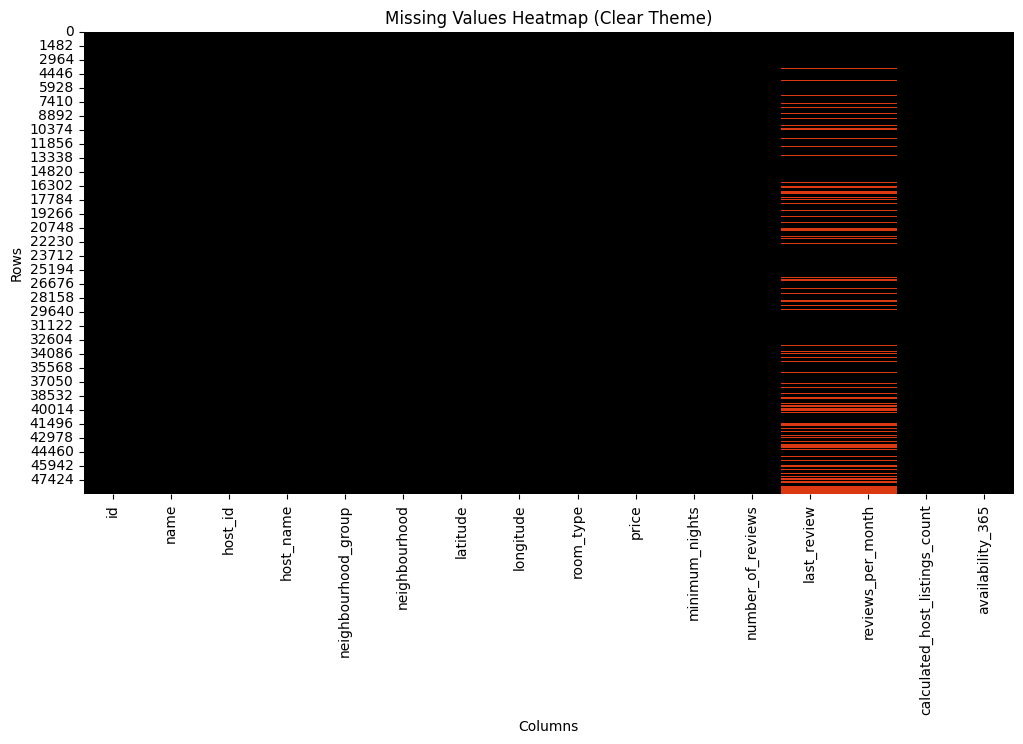

In [ ]:
# Visualizing the missing values
from matplotlib.colors import ListedColormap

# Create a custom colormap: Black for non-missing (False), Red (a distinct one) for missing (True)
custom_cmap = ListedColormap(['black', '#dc3912'])

plt.figure(figsize=(12, 6)) # Increased width for better spacing visualization
sns.heatmap(airbnb_df.isnull(), cbar=False, cmap=custom_cmap)
plt.title('Missing Values Heatmap (Clear Theme)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### What did you know about your dataset?

The dataset consists of ~48.8k unique datapoints about the listings across all boroughs in NYC.

The features (16 columns) are a mix of numeric data and text descritions.
 - **Metadata**: id, name, host_id, host_name
 - **Spacial Info**: neighbourhood_group, neighbourhood, latitude, longitude
 - **Operational Metrics**: room_type, price, minimum_nights, etc,.

 **Immediate Data Anomalies**:
- Text based columns like `name` and `host_name` were registered under the generic 'object' data type, indicating need for string conversion.
- No duplicates found, a clean dataset indeed.
- Spatial coordinates (`latitude` and `longitude`) were loaded cleanly as floating-points, so they were immediately ready for geographical mappings.

**Surface-Level Missing Data**:
- Descriptive text fields `name` and `host_name` were missing some 16 and 21 records resp., though it should be minor since they represent metadata.
- A big gap in info found from the `reviews_per_month` and `last_review`, with both columns missing about ~10k values.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
airbnb_df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [ ]:
# Dataset Describe
airbnb_df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


### Variables Description

* **id**: A unique identifier for each listing.
* **name**: The name of the listing.
* **host_id**: A unique identifier for the host of the listing.
* **host_name**: The name of the host.
* **neighbourhood_group**: The borough of New York City (e.g., Manhattan, Brooklyn).
* **neighbourhood**: The specific neighborhood within the borough.
* **latitude**: The latitude coordinate of the listing location.
* **longitude**: The longitude coordinate of the listing location.
* **room_type**: The type of room offered (e.g., Entire home/apt, Private room, Shared room).
* **price**: The price per night for the listing.
* **minimum_nights**: The minimum number of nights required for a booking.
* **number_of_reviews**: The total number of reviews the listing has received.
* **last_review**: The date of the last review.
* **reviews_per_month**: The average number of reviews received per month.
* **calculated_host_listings_count**: The number of listings the host has in total.
* **availability_365**: The number of days the listing is available throughout the year (365 days).

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable
for column in airbnb_df.columns:
    unique_count = airbnb_df[column].nunique()
    display_few = airbnb_df[column].unique()[:5]

    print(f"Column '{column}': {unique_count} unique values")
    print(f"Some values: {display_few}\n")

Column 'id': 48895 unique values
Some values: [2539 2595 3647 3831 5022]

Column 'name': 47905 unique values
Some values: ['Clean & quiet apt home by the park' 'Skylit Midtown Castle'
 'THE VILLAGE OF HARLEM....NEW YORK !' 'Cozy Entire Floor of Brownstone'
 'Entire Apt: Spacious Studio/Loft by central park']

Column 'host_id': 37457 unique values
Some values: [2787 2845 4632 4869 7192]

Column 'host_name': 11452 unique values
Some values: ['John' 'Jennifer' 'Elisabeth' 'LisaRoxanne' 'Laura']

Column 'neighbourhood_group': 5 unique values
Some values: ['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']

Column 'neighbourhood': 221 unique values
Some values: ['Kensington' 'Midtown' 'Harlem' 'Clinton Hill' 'East Harlem']

Column 'latitude': 19048 unique values
Some values: [40.64749 40.75362 40.80902 40.68514 40.79851]

Column 'longitude': 14718 unique values
Some values: [-73.97237 -73.98377 -73.9419  -73.95976 -73.94399]

Column 'room_type': 3 unique values
Some values: ['Private 

## 3. ***Data Wrangling***

### Data Wrangling Code

#### Handling missing values for required columns

Handle the missing values as identified for `reviews_per_month`,`last_review`, `name`, `host_name` and any required conversions

In [ ]:
# Missing Values before handling
print(airbnb_df[['reviews_per_month', 'last_review', 'name', 'host_name']].isnull().sum())

reviews_per_month    10052
last_review          10052
name                    16
host_name               21
dtype: int64


In [ ]:
# Update reviews_per_month with 0 for which no data was available
airbnb_df['reviews_per_month'] = airbnb_df['reviews_per_month'].fillna(0)

# Choosing format for column with date values, fill NaT when no data available
airbnb_df['last_review'] = pd.to_datetime(airbnb_df['last_review'], errors='coerce')
airbnb_df['last_review'] = airbnb_df['last_review'].fillna(pd.NaT)

# Few gaps in names, update to Unknown
airbnb_df['name'] = airbnb_df['name'].fillna('Unknown').astype(str)
airbnb_df['host_name'] = airbnb_df['host_name'].fillna('Unknown').astype(str)

print("Missing values after handling:")
print(airbnb_df[['reviews_per_month', 'last_review', 'name', 'host_name']].isnull().sum())

print("\nData types after handling:")
print(airbnb_df[['reviews_per_month', 'last_review', 'name', 'host_name']].dtypes)

Missing values after handling:
reviews_per_month        0
last_review          10052
name                     0
host_name                0
dtype: int64

Data types after handling:
reviews_per_month           float64
last_review          datetime64[ns]
name                         object
host_name                    object
dtype: object


#### Data types conversion for efficiency

Convert the `neighbourhood_group`, `neighbourhood`, and `room_type` columns to the 'category' data type to optimize memory usage. Assess the memory impact post conversion.

In [ ]:
save_mem_usage = airbnb_df.memory_usage(deep=True).sum() / (1024**2)
print(f"Pre-conversion Memory usage: {save_mem_usage:.2f} MB")

Pre-conversion Memory usage: 9.84 MB


In [ ]:
# Three columns suitable for categorical type as their unique value count is considerably good
categorical_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']
for col in categorical_cols:
    airbnb_df[col] = airbnb_df[col].astype('category')

# Updated data types for converted columns
airbnb_df[categorical_cols].dtypes

,0
neighbourhood_group,category
neighbourhood,category
room_type,category


Attempt to convert numerical columns to smaller integer types if their value ranges allow, to further reduce memory footprint without losing information.

In [ ]:
# Check the numerical columns
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                  'calculated_host_listings_count', 'availability_365']
airbnb_df[numerical_cols].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
for col in numerical_cols:
    # Check if conversion to int16 is safe without data loss (if max value fits in int16 range)
    if airbnb_df[col].max() <= np.iinfo(np.int16).max and airbnb_df[col].min() >= np.iinfo(np.int16).min:
        airbnb_df[col] = airbnb_df[col].astype('int16')
    else:
        # If int16 is not sufficient, try int32
        if airbnb_df[col].max() <= np.iinfo(np.int32).max and airbnb_df[col].min() >= np.iinfo(np.int32).min:
            airbnb_df[col] = airbnb_df[col].astype('int32')
        else:
            print(f"Column '{col}' cannot be safely downcasted to int16 or int32 without potential data loss.\
            Retains original Data type ({airbnb_df[col].dtype})")

# Updated data types for converted numerical columns
airbnb_df[numerical_cols].dtypes

,0
price,int16
minimum_nights,int16
number_of_reviews,int16
reviews_per_month,int16
calculated_host_listings_count,int16
availability_365,int16


In [ ]:
print(f"Memory usage BEFORE conversions: {save_mem_usage:.2f} MB")
print(f"Memory usage AFTER conversions : {airbnb_df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Memory usage BEFORE conversions: 19.22 MB
Memory usage AFTER conversions : 9.32 MB


#### Final DataFrame Info after type conversions

In [ ]:
airbnb_df.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48895 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48895 non-null  object        
 4   neighbourhood_group             48895 non-null  category      
 5   neighbourhood                   48895 non-null  category      
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  category      
 9   price                           48895 non-null  int16         
 10  minimum_nights                  48895 non-null  int16         
 11  nu

### What all manipulations have you done and insights you found?

#### Data Analysis Key Findings
- **Missing Value Handling**:
    - Missing values in the `reviews_per_month`, column were filled with 0 (numeric).
    - Missing values in the `name` and `host_name` columns were filled with 'Unknown' (text).
    - The `last_review` column was converted to `datetime` objects, with errors and remaining missing values filled with 'NaT', resulting in 10052 'NaT' (missing) values.
- **Data Types Optimization**:
    - `reviews_per_month` has a data type of 'float64'.
    - `last_review` is turned into relevant type 'datetime64[ns]'.
    - `name` and `host_name` have a data type of 'object' (string).
    - `neighbourhood_group`, `neighbourhood`, and `room_type` columns represented in 'category' type.
    - `calculated_host_listings_count` and `availability_365` columns in 'int16/32' type.

#### Insights and Key Findings
 Initially, the DataFrame consumed approximately 19.22 MB of memory, with data type conversions and categorical representations where possible the overall memory usage now reduced down to about 9.3 MB, representing a total memory reduction of more than 50% from the initial state without any kind of loss in critical information. Further analysis can be taken up now, with more optimized dataset, potentially leading to faster computations and reduced resource consumption.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Defining custom settings for plotting

In [ ]:
sns.set_theme()
label_padding = 10
title_padding = 15
custom_palette = sns.color_palette("dark:#5A9_r", as_cmap=False, n_colors=5)  # Green gradient for bars (boroughs)

### Fetching NYC Geographical Info

In [ ]:
# Install geopandas for advanced geographical plotting
!pip install geopandas

In [ ]:
# Download and load NYC borough boundaries GeoJSON
import geopandas as gpd
import requests
import os

# GeoJSON data link from the NYC.gov website
geojson_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Borough_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"
geojson_path = "nyc_borough_boundaries.geojson"

# Download the file if it doesn't exist
if not os.path.exists(geojson_path):
    print(f"Downloading from NYC.gov - {geojson_url}...")
    response = requests.get(geojson_url)
    response.raise_for_status() # Raise an error for bad status codes
    with open(geojson_path, "wb") as f:
        f.write(response.content)
    print("Download complete.")
else:
    print(f"\'{geojson_path}\' already exists, skipping download.\n")

# Load the GeoJSON file into a GeoDataFrame
nyc_boroughs = gpd.read_file(geojson_path)
nyc_boroughs.head()

Download complete.


,OBJECTID,BoroCode,BoroName,Shape__Area,Shape__Length,geometry
0,1,5,Staten Island,1.623620e+09,325903.403256,"MULTIPOLYGON (((-74.05051 40.56643, -74.05047 ..."
1,2,3,Brooklyn,1.934463e+09,726932.463960,"MULTIPOLYGON (((-73.86328 40.58389, -73.86381 ..."
2,3,4,Queens,3.041420e+09,887873.810812,"MULTIPOLYGON (((-73.82645 40.59054, -73.82643 ..."
3,4,1,Manhattan,6.366314e+08,359535.581244,"MULTIPOLYGON (((-74.01093 40.6845, -74.01193 4..."
4,5,2,Bronx,1.187201e+09,463135.604228,"MULTIPOLYGON (((-73.89681 40.79582, -73.89694 ..."


### Univariate Analysis - 4 Charts (1-4)

#### Chart - 1: Histogram & Boxplot - Distribution of Listing Prices

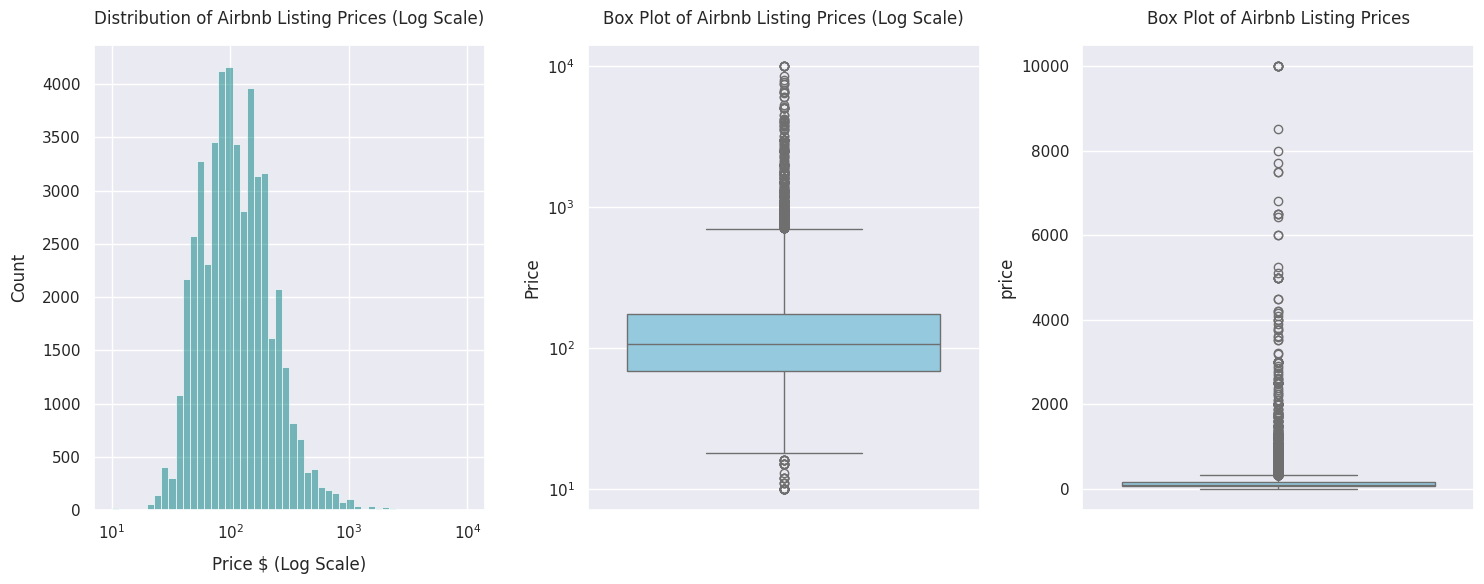

In [ ]:
plt.figure(figsize=(15, 6))

# Subplot 1: Histogram of Listing Prices
plt.subplot(1, 3, 1)
sns.histplot(airbnb_df['price'], bins=50, kde=True, log_scale=True, color='teal')
plt.title('Distribution of Airbnb Listing Prices (Log Scale)', pad=title_padding)
plt.xlabel('Price $ (Log Scale)', labelpad=label_padding)
plt.ylabel('Count', labelpad=label_padding)

# Subplot 2: Box Plot of Listing Prices (Log scaled for better visual interpretation)
plt.subplot(1, 3, 2)
sns.boxplot(y=airbnb_df['price'], color='skyblue', log_scale=True)
plt.title('Box Plot of Airbnb Listing Prices (Log Scale)', pad=title_padding)
plt.ylabel('Price')

# Subplot 3: Box Plot of Listing Prices (raw scale for comparison)
plt.subplot(1, 3, 3)
sns.boxplot(y=airbnb_df['price'], color='skyblue')
plt.title('Box Plot of Airbnb Listing Prices', pad=title_padding)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

To visualize the distribution of listing prices histogram is chosen, it is the ideal chart for showing the frequency distribution of a continuous variable (prices).

By looking at the `describe()` output for **price** (min 0, max 10000, mean 152), the data is highly skewed, so a logarithmic scale applied on the price (x-axis) to provide a clearer view of the distribution, especially for lower price ranges.

To complement the histogram, the box plot helps in easily identifying outliers. Together, these two charts provide a comprehensive view of the price distribution.

##### 2. What is/are the insight(s) found from the chart?

 - **Highly Skewed Distribution**: The histogram clearly shows that the price distribution is heavily right-skewed, even with a logarithmic scale. Majority of listings are in the lower price range, with a long tail extending to very high prices.

 - **Common Price Range**: The highest frequency of listings appears to be in the \$50 - \$200 range (estimated visually from the histogram). This suggests that most Airbnb listings are affordably priced.

 - **Outliers**: The box plot displays a lot of outliers at the higher end of the price spectrum. These are rare properties with exceptionally high prices compared to the majority, these may be luxury properties or properties that exist in highly desirable locations.

 - **Price Variation**: There's significant price variation across listings, from very low to extremely high, reflecting diverse offerings across different market segments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights gained from the price distribution charts can certainly lead to positive business impacts, and also highlight potential areas for concern:

**Positive Business Impact:**
 - **Targeted Pricing Strategies**: By Understanding the common price ranges and the long tail of high-priced listings,  hosts can strategically price their properties. Hosts with properties in the common price range (\$50-$200) can focus on competitive pricing for maximizing occupancy. And those with unique or luxury properties (like seen from outliers) can justify higher prices by highlighting premium features or locations.

 - **Market Positioning**: The trend of listings in the lower to mid-price range suggests a high demand for affordable accommodations. New hosts or those looking to maximize bookings could target this segment. Conversely, identifying gaps in the luxury segment might provide an opportunity for premium listings.

 - **Value Proposition Enhancement**: Hosts can analyze their pricing relative to the market median and adjust. If their price is above the median, they need to ensure their amenities, location, and guest experience justify the premium. If below, they might consider slight increases if their value proposition is strong.

**Insights Leading to Negative Growth (Potential Concerns):**
 - **Price Outliers (Risk of Overpricing)**: While some high-priced listings are justified, many outliers could represent properties that are overpriced relative to their value, leading to lower booking rates and occupancy. This could result in negative growth for individual hosts if their high price does not match market expectations.

 - **High Competition in Common Price Ranges**: The dense distribution of listings in the \$50-$200 range indicates significant competition. Without a strong differentiating factor, hosts in this segment might struggle to stand out, potentially leading to lower average daily rates or reduced bookings.

#### Chart - 2: Histogram - Distribution of Listing Prices with Custom Bins

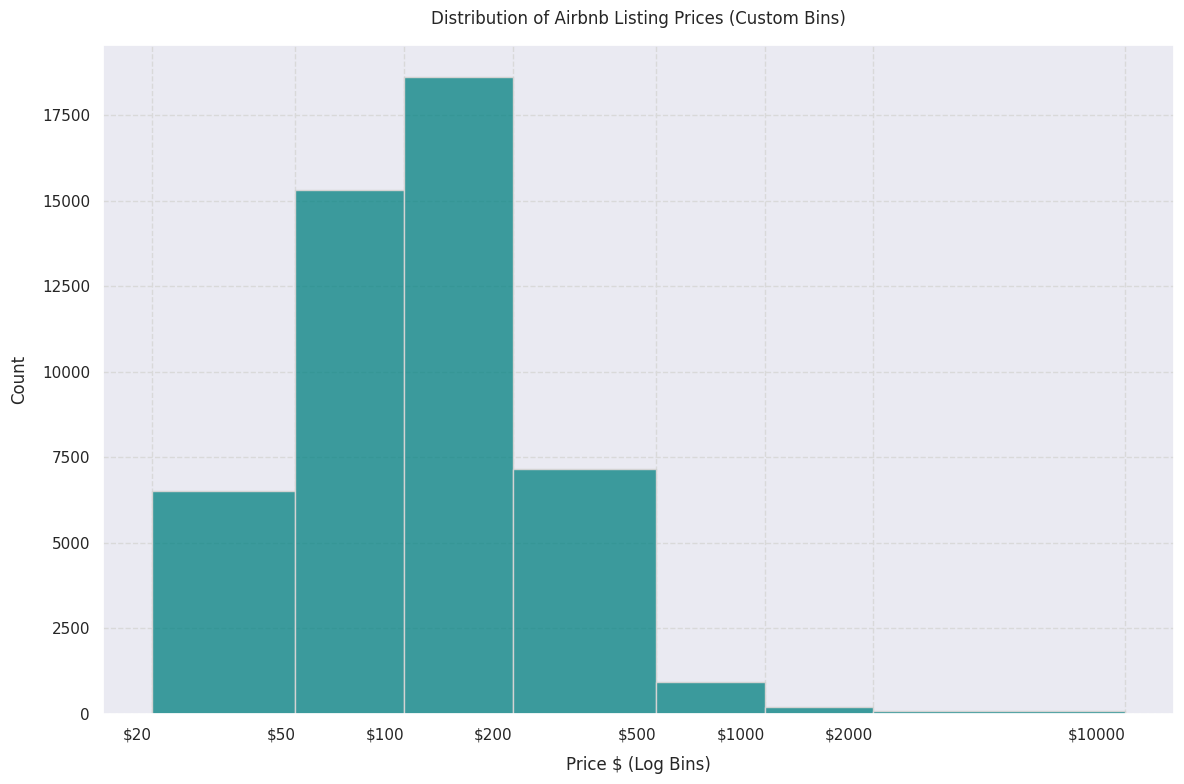

In [ ]:
# Filter out listings with price 0, as these might be anomalies (log(0) is undefined anyway)
filtered_prices = airbnb_df[airbnb_df['price'] > 0]['price']

# Define custom bins to strategically highlight different price ranges
# 20-50 (very affordable)
# 50-100 (affordable)
# 100-200 (mid-range/common)
# 200-500 (premium)
# 500-1000/2000 (high-end)
# >2000 (luxury/outliers)

# First bin starts at 20 to make comparison (bars) more realistic since not many listings are priced under 20$ (~50)
custom_price_bins = [20, 50, 100, 200, 500, 1000, 2000, filtered_prices.max()]

# Convert custom_price_bins to a numpy array for log transformation
custom_price_bins_arr = np.array(custom_price_bins)

# Log-transform the data, using log10 to align with typical log-scale interpretation for prices
log_filtered_prices = np.log10(filtered_prices)

# Log-transform the custom bins for the histogram function
log_bins = np.log10(custom_price_bins_arr)

plt.figure(figsize=(12, 8))

# Plot histogram of log-transformed data with log-transformed bins, log_scale not required
# The x-axis will be linear in log10(price) values, but we will label it with original prices
sns.histplot(log_filtered_prices, bins=log_bins, kde=False, color='teal', edgecolor='lightgray')

# Set x-ticks to display the original custom bin edges as labels
plt.xticks(log_bins, [f'${int(b)}' for b in custom_price_bins_arr], ha='right')

plt.title('Distribution of Airbnb Listing Prices (Custom Bins)', pad=title_padding)
plt.xlabel('Price $ (Log Bins)', labelpad=label_padding)
plt.ylabel('Count', labelpad=label_padding)
plt.grid(True, ls="--", c='0.85')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen to visualize the distribution of listing prices, but with a focus on **strategically allocating bins**. Instead of relying on automatic binning or a simple logarithmic scale, custom, non-uniform bins were defined as below

`custom_price_bins = [0, 50, 100, 200, 500, 1000, 2000, 10000]`

This approach was selected to highlight Key Price Segments, making it easier to see the concentration of listings within each. And to address skewness, a logarithmic scale is still applied to the x-axis to effectively visualize the wide range of prices and manage the heavy right-skewness of the data.

##### 2. What is/are the insight(s) found from the chart?

- **Dominance of Affordable and Mid-Range Listings**: The highest concentration of Airbnb listings falls within the \$50-200 price range, particularly between $100-200. This confirms that the NYC Airbnb market is largely inclined towards travelers seeking affordable to mid-range accommodations.

- **Significant drop at Premium Listings**: The count of listings drops significantly as the price increases beyond $200.

- **Small marked for Luxury Listings**: There is a significant drop in listings after crossing price range of \$500 and further with \$1000.

- **Visual Confirmation of Skewness**: Even with custom bins and a logarithmic scale, the visual representation clearly shows the heavy right-skewness of the price distribution, with the vast majority of listings at lower price points and a long tail extending to very expensive properties.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization & Market Positioning):**
- **Informed Pricing Strategy**: Hosts can use these specific price segment insights to position their listings. If their property aligns with the highly competitive \$100-200 range, they know to focus on differentiating factors like amenities, reviews, and host responsiveness. If they have a premium property, they understand it's a smaller, less competitive market where higher prices are more justifiable.

- **Marketing and Value Proposition**: Marketing efforts can be tailored. For affordable listings, emphasize value, location, and guest-friendly policies. For premium listings, highlight unique features, exclusive experiences, and concierge services.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Over-saturation in Mid-Range**: The high volume of listings in the \$50-200 range implies intense competition. Hosts in this segment, especially new ones, might struggle to secure bookings, unless they offer exceptional value they risk low occupancy.

- **Pricing Pressure on Budget Listings**: The significant number of listings under \$100 suggests that hosts in this segment face considerable pricing pressure. If they cannot maintain competitive pricing while covering costs, they might experience reduced profitability.

#### Chart - 3: Bar plot - Distribution of Listings by Borough

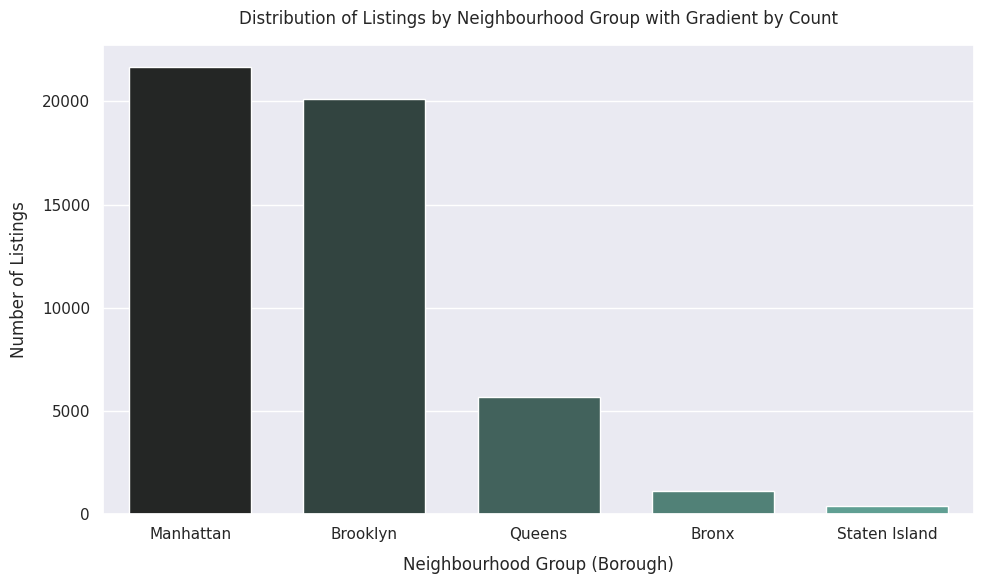

In [ ]:
plt.figure(figsize=(10, 6))

# Calculate listing counts for each neighbourhood_group
listing_counts = airbnb_df['neighbourhood_group'].value_counts().reset_index()
listing_counts.columns = ['neighbourhood_group', 'count']

# Sort the counts from highest to lowest for ordering the bars and gradient
listing_counts = listing_counts.sort_values(by='count', ascending=False)

# Create Barplot with hue based on count for gradient effect
sns.barplot(x='neighbourhood_group', y='count', data=listing_counts,
            hue='count', palette=custom_palette, legend=False, width=0.7,
            order=listing_counts['neighbourhood_group'])

plt.title('Distribution of Listings by Neighbourhood Group with Gradient by Count', pad=title_padding)
plt.xlabel('Neighbourhood Group (Borough)', labelpad=label_padding)
plt.ylabel('Number of Listings', labelpad=label_padding)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot (a type of bar chart) was selected for visualizing the distribution of listings by `neighbourhood_group` because it is highly effective for displaying the frequency of categorical variables. Each bar represents a `neighbourhood_group` (borough), and its height corresponds to the number of listings, making it easy to compare the market density across different areas of NYC. This chart provides a intuitive understanding of where Airbnb listings are most concentrated.

##### 2. What is/are the insight(s) found from the chart?

From the bar chart showing the distribution of listings by `neighbourhood_group`, the following insights can be derived:

 - **Manhattan Dominance**: Manhattan has the highest number of Airbnb listings by a significant margin, indicating it is the primary hub for rentals in NYC.

 - **Brooklyn as a Strong Second**: Brooklyn follows Manhattan with a substantial number of listings, positioning it as the second most popular borough for Airbnb hosts.

 - **Queens in Third Place**: Queens has a moderate number of listings, considerably less than Manhattan and Brooklyn but more than the other boroughs.

 - **Staten Island and The Bronx are Niche Markets**: Staten Island and The Bronx have a comparatively very low number of listings, suggesting they are either less popular among tourists/hosts, or less developed for the Airbnb market.

 - **Market Density Variation**: There is a clear uneven distribution of Airbnb listings across the boroughs, with a heavy concentration in Manhattan and Brooklyn compared to the others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from the distribution of listings by neighbourhood group can lead to both positive business impacts and highlight areas for potential negative growth.

**Positive Business Impact:**
 - **Targeted Market Entry (Market Positioning)**: For new hosts, this chart clearly identifies Manhattan and Brooklyn as high-density markets, suggesting high demand but also high competition. New hosts can decide whether to enter these competitive markets with unique offerings or target less saturated areas like Queens (for moderate competition) or even The Bronx/Staten Island (for niche opportunities with less competition but potentially lower demand).

 - **Resource Allocation**: Airbnb as a platform can use this information to focus marketing efforts. In less dense areas like Staten Island and The Bronx, they might offer incentives to attract more hosts, thus expanding their market coverage and increasing overall listing availability across NYC.

 - **Strategic Pricing**: Hosts in high-density areas (Manhattan, Brooklyn) might need to be more competitive with their pricing, focusing on value and guest experience. In contrast, hosts in less dense areas, if demand exists, might have more flexibility with pricing due to less direct competition.

**Insights Leading to Negative Growth (Potential Concerns):**
 - **Market Saturation**: The high concentration of listings in Manhattan and Brooklyn could indicate market saturation. This might lead to increased competition among hosts, potentially driving down prices or occupancy rates for individual listings, especially for those without unique selling points or excellent reviews. For new entrants, it could mean a slower start or difficulty achieving high booking rates, leading to negative growth if their property doesn't stand out.

 - **Underutilization in Low-Density Areas**: While The Bronx and Staten Island have fewer listings, without corresponding demand data, it's difficult to say if this represents an untapped market or simply a lack of traveler interest. If demand is low, hosts in these areas might experience lower occupancy and revenue, leading to negative growth despite less competition.

 - **Regulatory Risks**: High-density or the popular areas might also attract more regulatory scrutiny, which could negatively impact hosts through new restrictions or taxes, potentially hindering growth.

In summary, understanding the spatial distribution of listings helps hosts make informed decisions about where to list, how to price, and how to differentiate their offerings, while also being aware of the challenges posed by market density and competition.

#### Chart - 4: Bar Plot - Distribution of Listings by Room Type

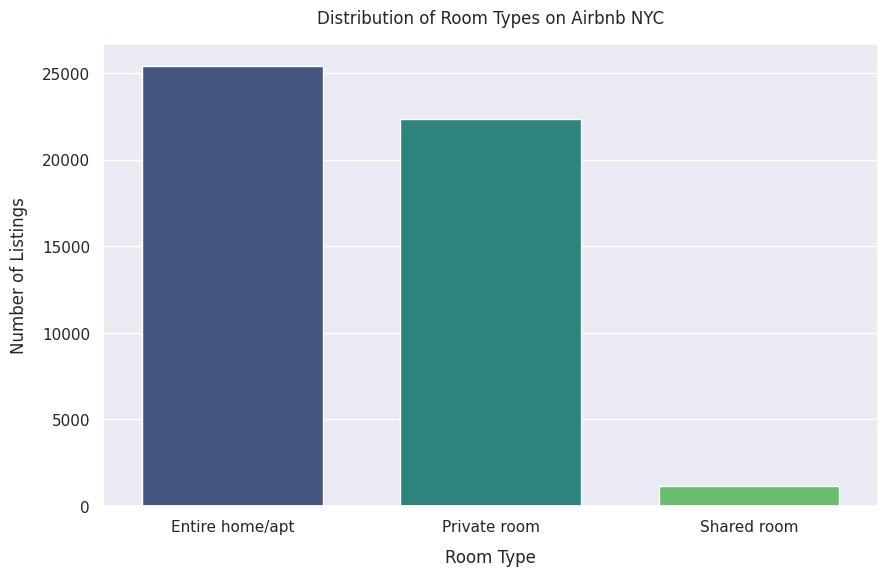

In [ ]:
plt.figure(figsize=(10, 6))

# Create count plot with hue based on room type
sns.countplot(x='room_type', data=airbnb_df, palette='viridis', hue='room_type', legend=False, width=0.7)
plt.title('Distribution of Room Types on Airbnb NYC', pad=title_padding)
plt.xlabel('Room Type', labelpad=label_padding)
plt.ylabel('Number of Listings', labelpad=label_padding)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot (a type of bar chart) was chosen because `room_type` is a categorical variable, and we want to visualize the frequency of each category. This chart provides a straightforward and intuitive way to compare the number of listings for each room type.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that "Entire home/apt" is the most common room type, followed by "Private room", with "Shared room" being the least common by a significant margin. This indicates a higher supply of private and entire rental options compared to shared spaces in NYC.

It can also imply that 'Shared room' may not be the desirable one for majority of the people looking for rentals in NYC.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**: For potential hosts, understanding the dominant room types can inform their investment decisions. If they are considering entering the market, they might lean towards "Entire home/apt" or "Private room" as these appear to be in higher supply and likely higher demand. For existing hosts, it highlights the competitive landscape. Those with "Shared room" listings might need to differentiate more or offer lower prices to attract guests, given the lower supply, which could indicate low demand. Conversely, the high supply of "Entire home/apt" and "Private room" means competition is fierce, requiring competitive pricing and good reviews.

**Potential Negative Impact**: The low number of "Shared room" listings could indicate low demand or cultural preference against shared spaces in NYC, making it a challenging market for new shared-room hosts. Without further data on booking rates, a high supply in "Entire home/apt" or "Private room" could also mean over-saturation and difficulty for new listings to gain traction unless they offer unique value.

### Bivariate Analysis - 10 Charts (5-14)

#### Chart - 5: Choropleth map - Geographical Concentration of Airbnb Listings

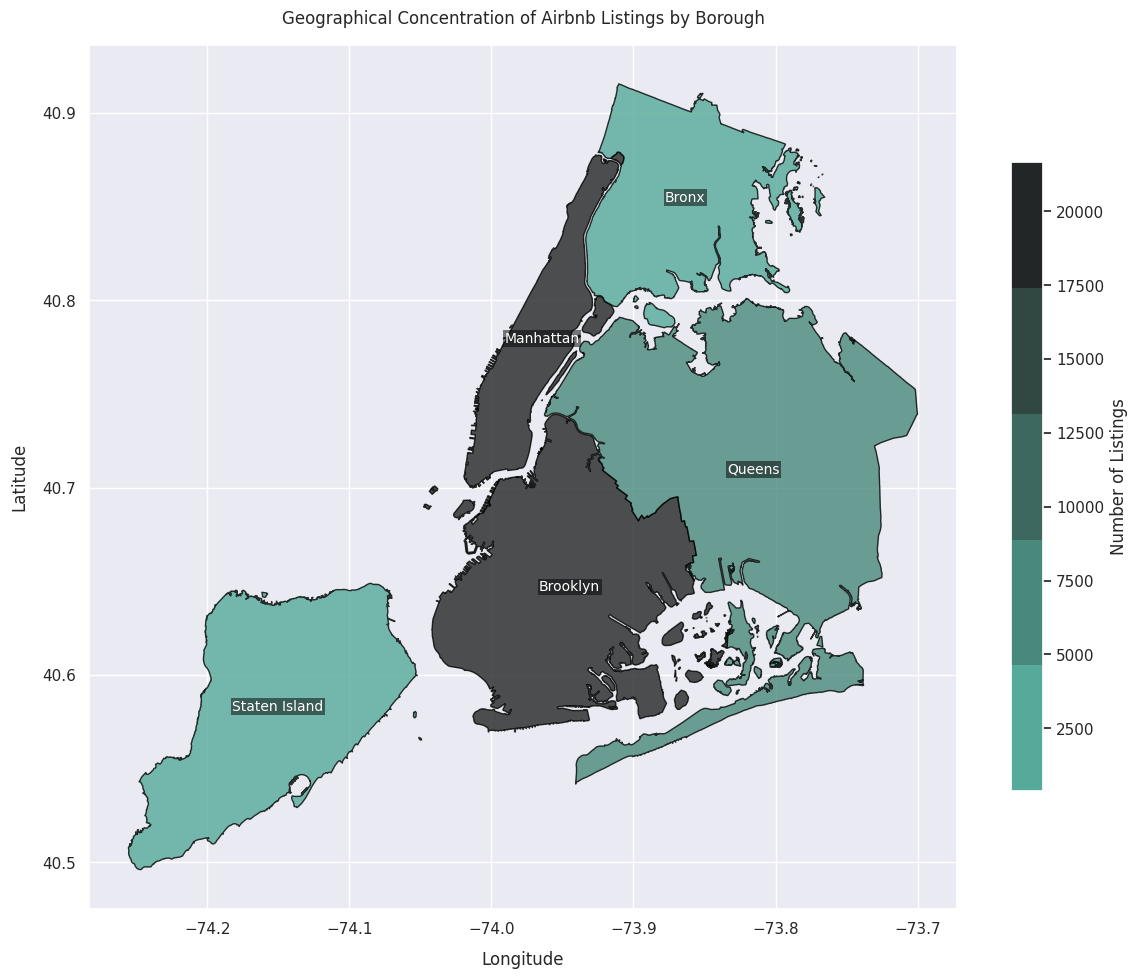

In [ ]:
from matplotlib.colors import LinearSegmentedColormap # For colormap gradient

# Create a GeoDataFrame from the airbnb_df for plotting
listings_gdf = gpd.GeoDataFrame(
    airbnb_df,
    geometry=gpd.points_from_xy(airbnb_df.longitude, airbnb_df.latitude),
    crs=nyc_boroughs.crs  # Use the same CRS as the borough boundaries
)

# Calculate listing counts per borough
borough_listing_counts = listings_gdf.groupby('neighbourhood_group', observed=False).size().reset_index(name='listing_count')

# Merge listing counts with nyc_boroughs GeoDataFrame, ensuring column for boroughs matches
# From previous inspection, 'BoroName' in nyc_boroughs corresponds to 'neighbourhood_group' in airbnb_df
nyc_boroughs_with_counts = nyc_boroughs.merge(
    borough_listing_counts,
    left_on='BoroName',
    right_on='neighbourhood_group',
    how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Create a LinearSegmentedColormap from the custom_palette for a gradient effect
borough_cmap_gradient = LinearSegmentedColormap.from_list("custom_gradient", custom_palette, N=5)

# Plot the borough boundaries, filling them with color based on 'listing_count'
nyc_boroughs_with_counts.plot(
    ax=ax,
    column='listing_count',
    cmap=borough_cmap_gradient,
    edgecolor='black',
    alpha=0.8,
    legend=True,
    legend_kwds={'label': 'Number of Listings', 'orientation': 'vertical', 'shrink': 0.7}
)

# Add borough names as labels on the map
for idx, row in nyc_boroughs_with_counts.iterrows():
    # Get the centroid of the polygon for text placement
    centroid = row.geometry.centroid
    ax.annotate(
        text=row['BoroName'],
        xy=(centroid.x, centroid.y), # Coordinates for the text
        xytext=(3, 3), # Offset for the text from the centroid
        textcoords="offset points",
        color='white',
        fontsize=10,
        fontweight='regular',
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1),
        ha='center', va='center'
    )

plt.title('Geographical Concentration of Airbnb Listings by Borough', pad=title_padding)
plt.xlabel('Longitude', labelpad=label_padding)
plt.ylabel('Latitude', labelpad=label_padding)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A choropleth map (geographical plota) with text labels was chosen to visualize the aggregate listing volume per borough across New York City. This view of data provides direct contrast of areas with higher or lower total volumes of Airbnb listings by using a color gradient and reveals where Airbnb supply is concentrated.

##### 2. What is/are the insight(s) found from the chart?

- **Manhattan and Brooklyn Dominate Listing Volume**: These two boroughs are depicted with the darkest shades, clearly indicating the highest number of Airbnb listings. Manhattan leads, Brooklyn follows closely.

- **Moderate Listing Activity in Queens**: Queens shows a noticeably lower listing volume compared to Manhattan and Brooklyn, although significantly higher than than the Bronx and Staten Island.

- **Minimal Airbnb Presence in The Bronx and Staten Island**: These boroughs are the lightest in color, signifying a very low density and volume of Airbnb listings. This suggests they are either less popular among tourists/hosts or less developed as Airbnb markets.

-  **Clear Visual Confirmation of Market Concentration**: The choropleth map vividly illustrates the uneven distribution of Airbnb supply across NYC, with a heavy concentration in major boroughs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
 - **Strategic Investment and Market Entry (Revenue Optimization)**: For prospective hosts or real estate investors, the map clearly identifies high-volume areas (Manhattan, Brooklyn) where demand is likely high. This can guide investment decisions towards properties in these proven Airbnb markets for potentially higher returns. Conversely, it also visually highlights lower-volume markets (The Bronx, Staten Island) which might represent untapped potential if demand exits, or offer a niche market for hosts seeking less competition.

 - **Targeted Marketing and Resource Allocation**: Airbnb as a platform, or local businesses serving hosts/guests, can use this data to strategically concentrate marketing efforts in high-volume boroughs. This ensures resources are efficiently utilized where the Airbnb presence is strongest, potentially maximizing bookings and host satisfaction.


**Insights Leading to Negative Growth (Potential Concerns):**
 - **Market Saturation and Intense Competition**: The high volume of listings in Manhattan and Brooklyn strongly suggests market saturation. Existing hosts might face lower occupancey while new entrants in these areas might struggle to achieve profitability.

 - **Risk of Low Demand in Sparse Areas**: While The Bronx and Staten Island have low listing volumes, this scarcity might be due to genuinely low tourist demand rather than solely an untapped market. Hosts should get their research right before entering to business in these areas.

#### Chart - 6: Stacked Bar - Distribution of Listings by Stay Type across Room Type

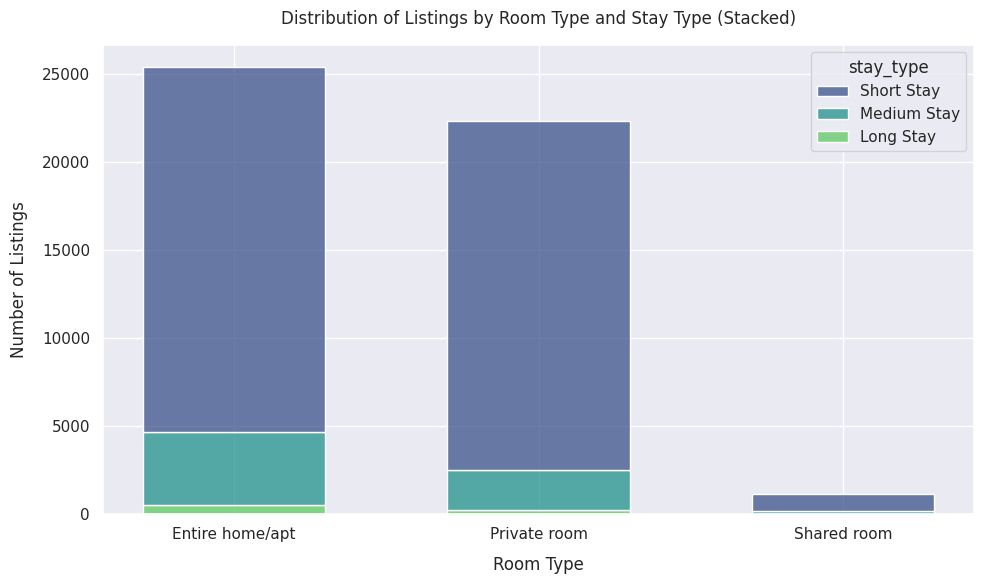

In [ ]:
# Define 'stay_type' based on 'minimum_nights'
# Short Stay: 1-7 nights
# Medium Stay: 8-30 nights
# Long Stay: >30 nights
airbnb_df['stay_type'] = pd.cut(airbnb_df['minimum_nights'],
                                bins=[0, 7, 30, airbnb_df['minimum_nights'].max()],
                                labels=['Short Stay', 'Medium Stay', 'Long Stay'],
                                right=True,
                                include_lowest=True)

plt.figure(figsize=(10, 6))

# Create histogram plot with hue based on stay type with stacking
sns.histplot(x='room_type', hue='stay_type', data=airbnb_df, palette='viridis', multiple='stack', shrink=0.6)
plt.title('Distribution of Listings by Room Type and Stay Type (Stacked)', pad=title_padding)
plt.xlabel('Room Type', labelpad=label_padding)
plt.ylabel('Number of Listings', labelpad=label_padding)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart (using countplot with `hue`) was selected to visualize the distribution of listings across `room_type` and the newly created `stay_type` categories. This chart shows the frequency of listings for each room type, with distribution of Stay type. It allows for comparing the most affective combination for listing.

##### 2. What is/are the insight(s) found from the chart?

- **Dominance of Short Stays**: Across all `room_type` categories, 'Short Stay' (1-7 nights) is overwhelmingly the most frequent `stay_type`. This indicates that the majority of Airbnb bookings in NYC are for shorter durations, catering to tourists or brief visits.

- **'Entire home/apt' and 'Private room' for Short Stays**: Both 'Entire home/apt' and 'Private room' types show a high number of listings for the 'Short Stay' guests. 'Entire home/apt' has the highest number of short stays.

- **Reduced Medium and Long Stays**: The number of listings for 'Medium Stay' (8-30 nights) and especially 'Long Stay' (>30 nights) drops significantly for all room types. This suggests a lower supply or demand for extended stays across all boroughs.

The overall pattern reinforces that the NYC Airbnb market primarily caters to short-term accommodations, offering flexibility to travelers who are often on shorter trips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights from the distribution of listings by `room_type` and `stay_type` offer valuable information for both positive business impact and potential risks.

**Positive Business Impact:**
- **Targeted Investment and Listing Strategy**: For new hosts, this chart clearly indicates that the highest demand and supply are for 'Short Stay' properties, particularly 'Entire home/apt' and 'Private room'. This guides new investments towards properties suitable for short-term rentals, allowing hosts to align with the dominant market trend.

- **Optimized Pricing for Short Stays**: Hosts can leverage the high demand for 'Short Stay' listings to optimize their pricing strategies, potentially charging a premium during peak seasons.

- **Tailored Marketing Campaigns**: Airbnb as a platform, and individual hosts, can tailor marketing campaigns based on these findings. promoting short-term 'Entire home/apt' and 'Private room' options to tourists for potentially higher occupancy.


**Insights Leading to Negative Growth (Potential Concerns):**
- **Intense Competition in Short-Stay Market**: The overwhelming concentration of 'Short Stay' listings, especially for 'Entire home/apt' and 'Private room', indicates high market saturation. This situation can lead to pressure to get the competitive pricing while increasing marketing costs to make the listing standout from the rest. For new hosts it makes it hard to get the visibility and may lead to potentially slow growth or losess.

- **Operational Challenges for Short Stays**: While profitable, frequent short stays involve higher operational overhead (cleaning, check-in/out management, etc.,). If not managed efficiently, these costs can negate profit margins despite high booking volumes.

- **Untapped Potential in Long Stays**: May be the market not inclided towards the longer stays, but it's also possible that only few hosts took the niche. Either way the long stay types might have untapped potential waiting to be discovered and serviced to guests.

#### Chart - 7: Box plot - Price Distribution by Borough

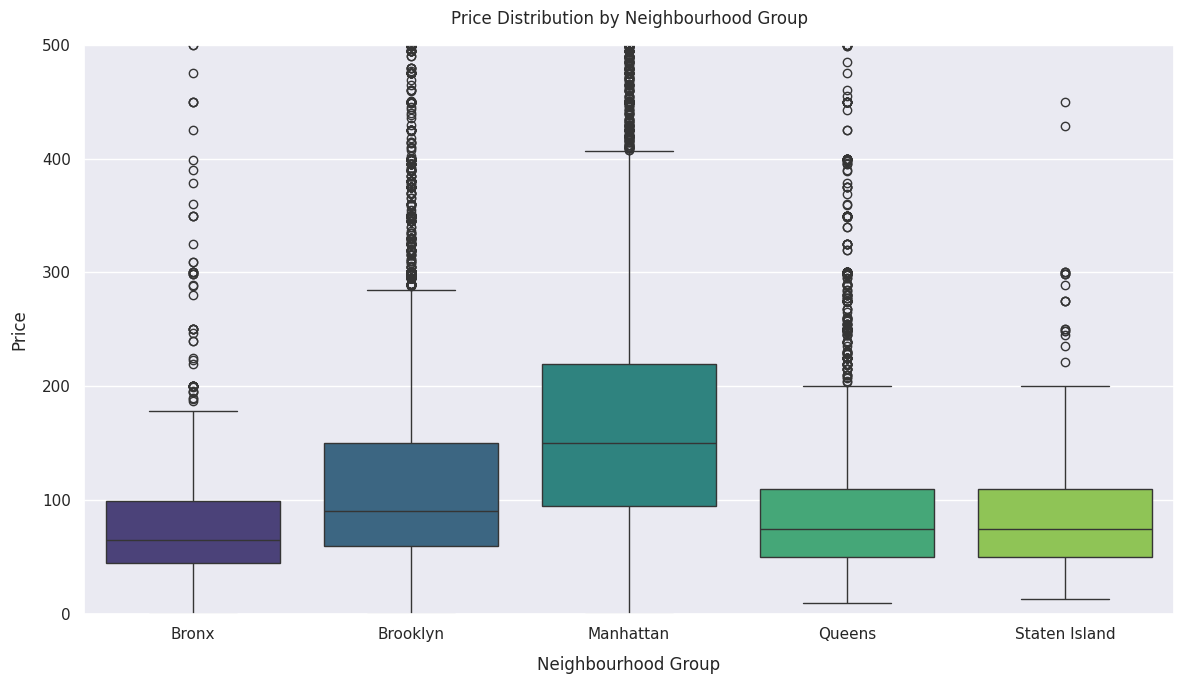

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='neighbourhood_group', y='price', data=airbnb_df, palette='viridis', hue='neighbourhood_group', legend=False)
plt.title('Price Distribution by Neighbourhood Group', pad=title_padding)
plt.xlabel('Neighbourhood Group', labelpad=label_padding)
plt.ylabel('Price', labelpad=label_padding)
plt.ylim(0, 500) # Setting a reasonable y-axis limit to better visualize the bulk of the data
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected to visualize the relationship between `neighbourhood_group` and `price` since it's highly effective for comparing the distribution of a continuous variable (price) across multiple categorical groups (`neighbourhood_group`s). It clearly displays the median, quartiles and potential outliers for each borough.

Given the likely presence of extreme price outliers in the dataset, applying a `plt.ylim(0, 500)` allows to focus on the bulk of the data distribution.

##### 2. What is/are the insight(s) found from the chart?

From the box plot showing the price distribution by `neighbourhood_group`, the following key insights can be derived:

- **Manhattan is the most expensive borough**: Manhattan consistently shows the highest median price, indicating it is the most premium location for Airbnb listings. It also has a wide interquartile range (IQR), suggesting a diverse range of prices even within its high-end market.

- **Brooklyn offers mid-range pricing**: Brooklyn's median price is lower than Manhattan's but significantly higher than the other boroughs. It also presents a substantial IQR, reflecting its varied pricing and property types.

- **Queens is reasonbly alongside Bronx and Staten Island**: Queens and others have a lower median price compared to Manhattan and Brooklyn, making them a more budget-friendly option for guests.

- **Price Hierarchy by Borough**: There's a clear and expected hierarchy in pricing: Manhattan > Brooklyn > Queens > Staten Island > The Bronx. This reflects the general perception of desirability, accessibility, and economic value of these NYC boroughs.

- **Outliers**: While the `ylim` is set to 500, it's evident that Manhattan and Brooklyn, in particular, still have a significant number of listings that are priced above this threshold, indicating comparitively higher listings of luxury or high-value properties that command premium rates.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization & Market Positioning):**
 - **Strategic Pricing by Location**: Hosts can set prices more strategically based on their `neighbourhood_group`. In Manhattan, hosts can command premium prices, focusing on luxury amenities and experiences. In Brooklyn, a balanced approach combining competitive pricing with strong value proposition will be key. In Queens, The Bronx, and Staten Island, hosts should focus on affordability and unique local experiences to attract budget-conscious travelers.

 - **Targeted Investment Decisions**: Investing in Manhattan or prime Brooklyn locations is likely to yield higher average daily rates, but also comes with higher property costs and competition.

 - **Optimizing Occupancy vs. ADR**: Hosts in high-price areas (Manhattan) might prioritize maximizing their Average Daily Rate (ADR), accepting potentially lower occupancy. Hosts in more affordable areas (The Bronx, Staten Island) might prioritize maximizing occupancy with competitive pricing, aiming for consistent bookings.

**Insights leading negative growth (Potential Concerns):**
 - Manhattan and Brooklyn being the highly volatile pricing markets, some listings with well above median pricing could end up with less occupancy even though the pricing may be strategically set up due to lot of similar or lower priced listings competively available within the neighbourhood.

#### Chart - 8: Bar plot - Average Price by Borough

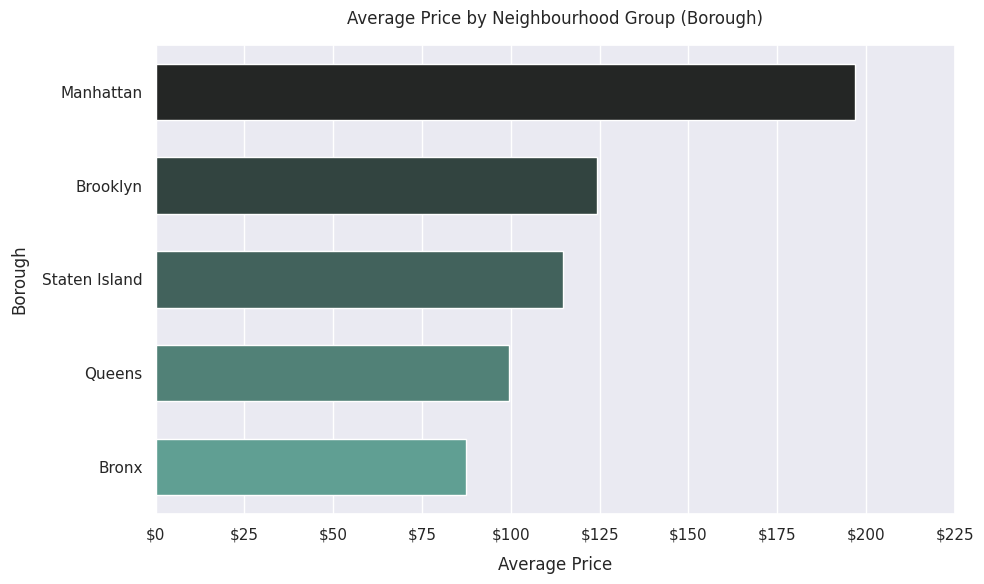

In [ ]:
# Calculate the average price for each neighbourhood_group
avg_price_by_borough = airbnb_df.groupby('neighbourhood_group', observed=False)['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='price', y='neighbourhood_group', data=avg_price_by_borough, hue='price',
            legend=False, width=0.6, order=avg_price_by_borough['neighbourhood_group'],
            palette=custom_palette)

plt.title('Average Price by Neighbourhood Group (Borough)', pad=title_padding)
plt.xlabel('Average Price', labelpad=label_padding)
plt.ylabel('Borough', labelpad=label_padding)

# Update labels by prepending '$' to the numerical value of each tick
locs, labels = plt.xticks()
plt.xticks(locs, [f'${int(loc)}' for loc in locs])

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot was chosen to visualize the average price by `neighbourhood_group`, this chart clearly shows which boroughs have higher or lower average listing prices, making it easy to identify pricing disparities and market value differences between the geographical areas.

##### 2. What is/are the insight(s) found from the chart?

- **Manhattan is the most expensive borough**: Manhattan has the highest average listing price, significantly exceeding all other boroughs. This aligns with its reputation as a prime location in NYC.

- **Brooklyn follows Manhattan**: Brooklyn has the second-highest average price, indicating it's also a popular and relatively expensive area for Airbnb listings.

- **Rest are moderately priced**: Staten Island is reasonbly affordable while Queens and Bronx follows more budget pricing.

- **Clear Price Hierarchy**: There's a clear hierarchy in average prices across the boroughs: Manhattan > Brooklyn > Staten Island > Queens > Bronx and it exactly aligns with the pricing variability.

- **Staten Island holding Great Pricing**: Although Staten Island has the lowest listings volume the average pricing of the market here conveys a different perspective on the property locations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**
- **Strategic Pricing by Location**: Hosts can set prices more strategically based on their `neighbourhood_group`, considering the average pricing hosts can go higher by distinguishing as more premium options to generate more revenue or can go lower by presenting as relatively affordable option to drive more occupancy.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Price Ceiling in Affordable Boroughs**: In boroughs like The Bronx and Queens, there might be a higer price ceiling due to market expectations. Hosts in these areas could struggle to significantly increase their prices, potentially limiting revenue growth if operational costs rise.

- **Misinterpretation of Staten Island's Average Price**: While Staten Island has a relatively good average price, its low listing volume means this average might be skewed by a few high-priced unique listings. New hosts entering this market, should consider demand and other factors before listing for the competitive pricing here.

#### Chart - 9: Box plot - Price Distribution by Room Type

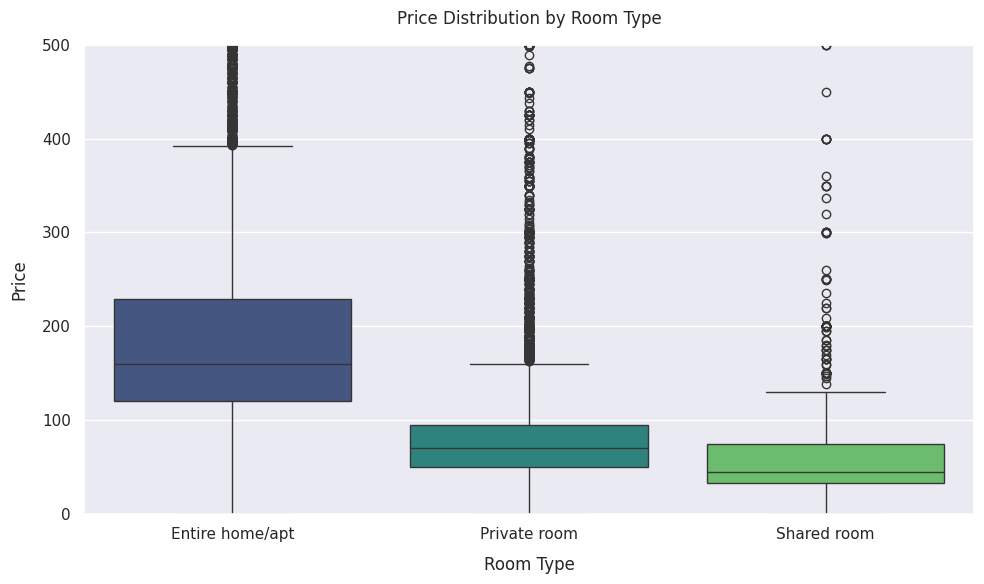

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='price', data=airbnb_df, palette='viridis', hue='room_type', legend=False)
plt.title('Price Distribution by Room Type', pad=title_padding)
plt.xlabel('Room Type', labelpad=label_padding)
plt.ylabel('Price', labelpad=label_padding)
plt.ylim(0, 500) # Setting a reasonable y-axis limit to better visualize the bulk of the data
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to visualize the relationship between `room_type` and `price` because it effectively displays the median, quartiles, and potential outliers for each room type.

The `ylim(0, 500)` was applied to focus on the bulk of the data, as prices can have extreme outliers that otherwise compress the view of the more common price distributions.

##### 2. What is/are the insight(s) found from the chart?

- **"Entire home/apt" is the most expensive room type**: This category shows the highest median price and a wider interquartile range (IQR) compared to other room types, indicating that guests are willing to pay more for privacy and full accommodations.

- **"Private room" offers a mid-range price point**: Private rooms have a lower median price than entire homes/apartments but enough variability for catering to range of pricings for the market.

- **"Shared room" is the most affordable option**: Shared rooms have the lowest median price positioning in as the budget-friendly choice.

- **Outliers across all room types**: "Entire home/apt" typically shows more extreme high-price outliers, suggesting luxury or highly unique properties often exits within the segment.

- **Price difference is significant**: There is a clear and expected hierarchy in pricing: Entire home/apt > Private room > Shared room and this also aligns with the listings volume of these room types.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization & Market Positioning):**
- **Strategic Pricing**: Hosts with "Entire home/apt" listings can aim for higher price points, while "Private room" hosts can position themselves as a value-for-money option, balancing price with amenities. "Shared room" hosts know they are in the budget segment and should focus on competitive pricing.

- **Differentiation and Value Proposition**: Hosts can differentiate their listings within their room type. A "Private room" host in the upper end of its price range needs to ensure superior amenities or service. A "Shared room" host might offer unique experiences or prime location to stand out.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Competitive Pressure for Private Rooms**: Being in budget with substantial pricing variability, "Private room" hosts might face significant competitive pressure, needing to constantly adjust prices or enhance offerings to maintain occupancy, potentially leading to lower margins if not managed effectively.

- **Lack of Diversification**: Hosts who only offer one room type might be vulnerable to market fluctuations impacting that specific segment. Lack of diversification across room types could limit overall business growth.

#### Chart - 10: Bar plot - Average Price by Room Type

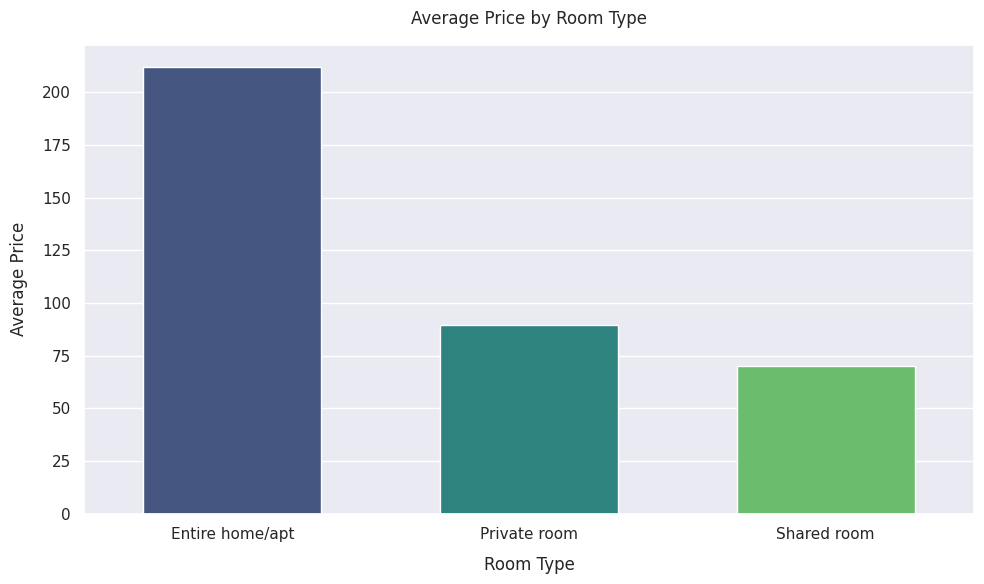

In [ ]:
# Calculate the average price for each room_type
avg_price_by_room_type = airbnb_df.groupby('room_type', observed=False)['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='room_type', y='price', data=avg_price_by_room_type, hue='room_type', palette='viridis', legend=False,
            order=avg_price_by_room_type['room_type'], width=0.6)
plt.title('Average Price by Room Type', pad=title_padding)
plt.xlabel('Room Type', labelpad=label_padding)
plt.ylabel('Average Price', labelpad=label_padding)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to visualize the average price by `room_type` as it clearly shows which room types command higher or lower average listing prices, making it easy to identify market value differences between the various accommodation types.

##### 2. What is/are the insight(s) found from the chart?

- **'Entire home/apt' is the most expensive**: Having highest average price, significantly exceeding 'Private room' and 'Shared room'. This indicates that guests are willing to pay a premium for privacy, space, and exclusive access to a full accommodation.

- **'Private room' is mid-range while 'Shared Room' is most affordable**: 'Private room' listings have a lower average price than 'Entire home/apt', and 'Shared room' catering to budget-conscious travelers.

- **Clear Price Hierarchy**: There's a distinct and expected hierarchy in average prices across room types: 'Entire home/apt' > 'Private room' > 'Shared room'. This reflects different levels of privacy, amenities, and space offered, which directly influence their market value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization & Market Positioning):**
 - **Strategic Pricing**: Hosts can use the average price hierarchy to fine-tune their pricing strategy to suit the market demand for the particular accomodation type.

 - **Market Differentiation**: Hosts can identify opportunities to differentiate their offerings within each room type to command prices closer to the higher end of its average. A 'Shared room' host could focus on creating a vibrant community atmosphere while 'Entire home/apt' could focus on making the space more private and premium ambience.

**Insights Leading to Negative Growth (Potential Concerns):**
 - **Market Saturation in 'Entire home/apt'**: While 'Entire home/apt' commands the highest average prices, it's also a highly competitive segment. If the market becomes oversaturated, new listings or those without strong differentiating factors might struggle to achieve high occupancy or premium pricing, leading to reduced profitability and potential negative growth.

#### Chart - 11: Bar plot - Estimated Revenue by Borough

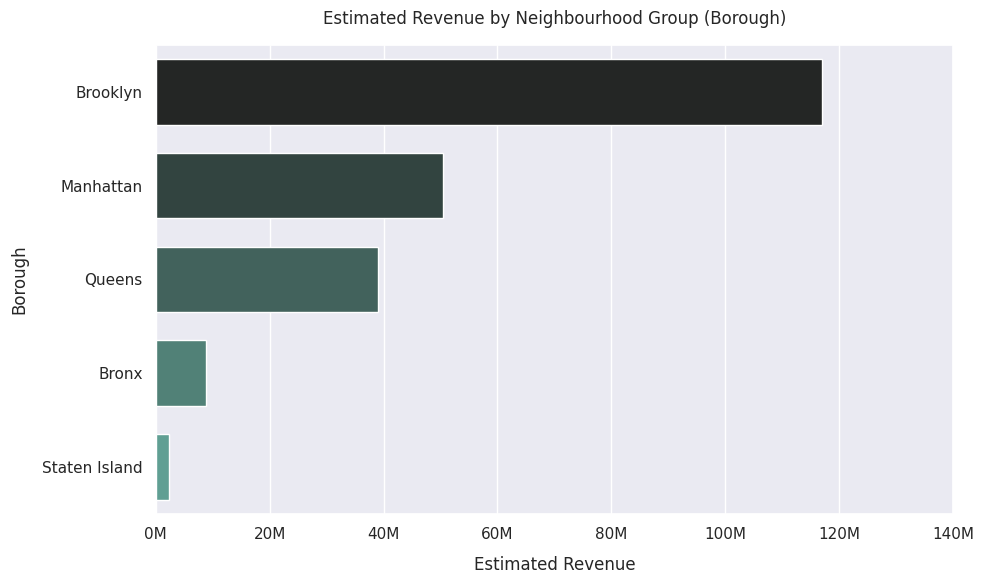

In [ ]:
# Calculate estimated revenue for each listing if not already present
if 'estimated_revenue' not in airbnb_df.columns:
    airbnb_df['estimated_revenue'] = airbnb_df['price'] * (365 - airbnb_df['availability_365'])

# Calculate the total estimated revenue for each neighbourhood_group
avg_revenue_by_borough = airbnb_df.groupby('neighbourhood_group', observed=False)['estimated_revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='estimated_revenue', y='neighbourhood_group', data=avg_revenue_by_borough, hue='estimated_revenue',
            palette=sns.color_palette("dark:#5A9_r", as_cmap=False, n_colors=5), legend=False,
            order=avg_revenue_by_borough['neighbourhood_group'], width=0.7)
plt.title('Estimated Revenue by Neighbourhood Group (Borough)', pad=15)
plt.xlabel('Estimated Revenue', labelpad=10)
plt.ylabel('Borough', labelpad=10)

locs, xticks = plt.xticks()
plt.xticks(locs, [f'{int(num * 1e-6)}M' for num in locs])
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar plot was chosen to effectively display the estimated revenue generated from each Borough. The revenue figures are the estimates produced based on the listings' price and their estimated occupancy, calculated as

Estimated Revenue = `price * (365 - availability_365)`

Horizontally sorted bars, along with the chosen color gradient, allow for a clear comparison of each borough's revenue contribution, highlighting the top-performing areas. This helps in easily identifying which boroughs are the largest revenue drivers for Airbnb.

##### 2. What is/are the insight(s) found from the chart?

- **Brooklyn Leads in Estimated Revenue**: Brooklyn generates the highest total estimated revenue among all boroughs, significantly surpassing Manhattan and Queens. This indicates that while Manhattan might have higher average prices, Brooklyn's listings collectively achieve higher overall booking activity.

- **Queens with Moderate Revenue**: Queens holds the third position, with estimated revenue considerably lower than Brooklyn and Manhattan but still significantly higher than The Bronx and Staten Island.

- **Minimal Revenue from The Bronx and Staten Island**: The Bronx and Staten Island show very low estimated revenues, suggesting they are in overall either much smaller markets for Airbnb or have significantly lower booking rates.

- **Revenue Hierarchy**: There is a clear hierarchy in total estimated revenue across the boroughs: Brooklyn > Manhattan > Queens > The Bronx > Staten Island. This ranking diverges from the Boroughs' listing count or average price, indicating varying levels of market activity and occupancy rates across the boroughs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization & Market Positioning):**
- **Strategic Investment and Market Entry**: For new hosts or investors, this chart strongly suggests that Brooklyn and secondly Manhattan offers the highest potential for total revenue generation. Investing in properties in Brooklyn might yield better overall returns compared to other boroughs, even Manhattan, especially if occupancy rates are higher.

- **Occupancy-Focused Strategies**: Hosts in Manhattan, despite having higher average prices, generate less total revenue than Brooklyn. This insight suggests that Manhattan hosts might need to shift their focus from solely maximizing price to improving occupancy rates.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Risk of Over-saturation in Brooklyn**: The high revenue generation in Brooklyn might attract an influx of new listings, potentially leading to over-saturation and increased competition. This could drive down individual host profitability and occupancy rates over time if the supply outpaces demand, leading to negative growth for new entrants and even existing listings.

- **Underperforming High-Value Assets in Manhattan**: While Manhattan listings often command premium prices, their lower total estimated revenue compared to Brooklyn suggests that many high-priced listings might experience lower occupancy. This implies that a high price doesn't always translate to high total revenue, and could impact profitability.

#### Chart - 12: Bar plot - Average Occupancy Rate by Borough

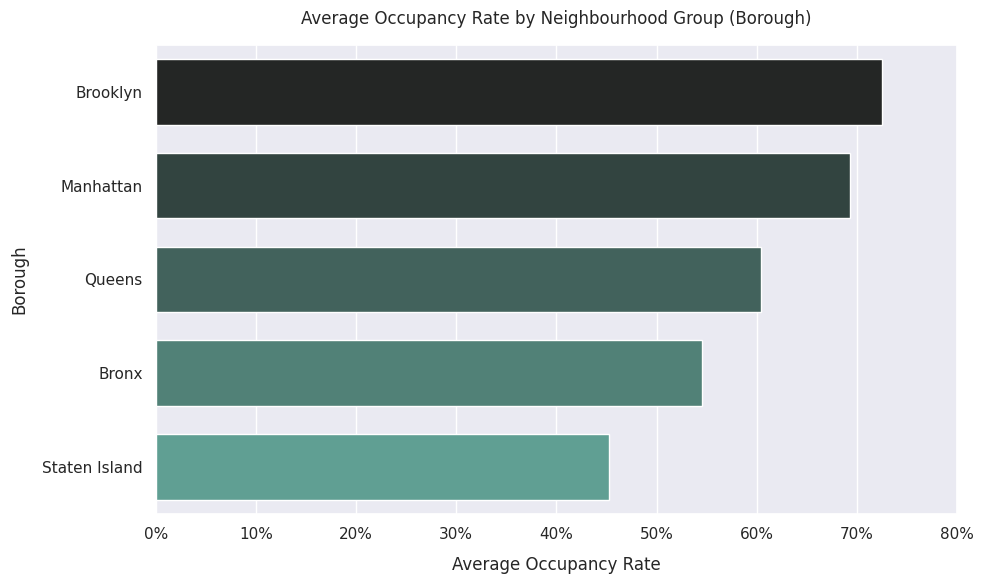

In [ ]:
# Calculate occupancy rate for each listing
# Occupancy rate = (365 - availability_365) / 365
airbnb_df['occupancy_rate'] = (365 - airbnb_df['availability_365']) / 365

# Calculate the average occupancy rate for each neighbourhood_group
avg_occupancy_by_borough = airbnb_df.groupby('neighbourhood_group', observed=False)['occupancy_rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='occupancy_rate', y='neighbourhood_group', data=avg_occupancy_by_borough, hue='occupancy_rate',
            order=avg_occupancy_by_borough['neighbourhood_group'],
            palette=custom_palette, legend=False, width=0.7)

plt.title('Average Occupancy Rate by Neighbourhood Group (Borough)', pad=title_padding)
plt.xlabel('Average Occupancy Rate', labelpad=label_padding)
plt.ylabel('Borough', labelpad=label_padding)

locs, labels = plt.xticks()
plt.xticks(locs, labels=[f'{int(rate * 100)}%' for rate in locs])

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar plot was selected to visualize the average occupancy rate for each borough. This chart type is highly effective for comparing a continuous numerical variable (average occupancy rate) across categorical groups (boroughs).

The horizontal orientation, coupled with sorting the bars, allows for easy comparison and best compliments the revenue estimates providing further insights.

##### 2. What is/are the insight(s) found from the chart?

- **Brooklyn Leads in Average Occupancy**: Manhattan exhibits the highest average occupancy rate among all boroughs. This suggests that despite potentially higher prices and competition, listings in Manhattan are booked for a larger proportion of the year, indicating strong demand.
- **Manhattan and Queens Follow**: They show average occupancy rates, falling behind Brooklyn but still indicating healthy booking activity.
- **Lower Occupancy in The Bronx and Staten Island**: The Bronx and Staten Island have significantly lower average occupancy rates. This implies that they could be due to lower tourist demand, less developed infrastructure for tourism, or other factors.
- **Occupancy Aligns with Revenue**: The ranking of boroughs by average occupancy rate perfectly aligns with their estimated revenue, reinforcing occupancy is in fact the leading factor than the average pricing in deciding the revenue generation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Market Positioning & Revenue Optimization):**
- **Strategic Investment and Market Entry**: This shows Brooklyn with excellent occupancy potential, even if it might come with higher property costs or operational challenges could generate huge revenue.
- **Performance Benchmarking**: Hosts can use these average occupancy rates as a benchmark, when in lower occupancy, it signals an opportunity to adjust pricing, improve amenities, or enhance their marketing to align with the borough's potential.
- **Optimizing for Occupancy**: In high-occupancy boroughs hosts might be able to maintain higher prices due to consistent demand, conversely for others more competitive pricing will be a continuous iteration to maximize the occupancy.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Low Demand in The Bronx and Staten Island**: The significantly lower average occupancy rates in The Bronx and Staten Island indicate a fundamental challenge in attracting guests. Hosts in these areas carry higher in generating revenue even to break even margins.
- **Operational Burden in High-Occupancy Areas**: High occupancy, while good for revenue, also means higher operational demands (more frequent cleaning, guest communication, maintenance).

#### Chart - 13: Bar plot - Number of Reviews by Room Type

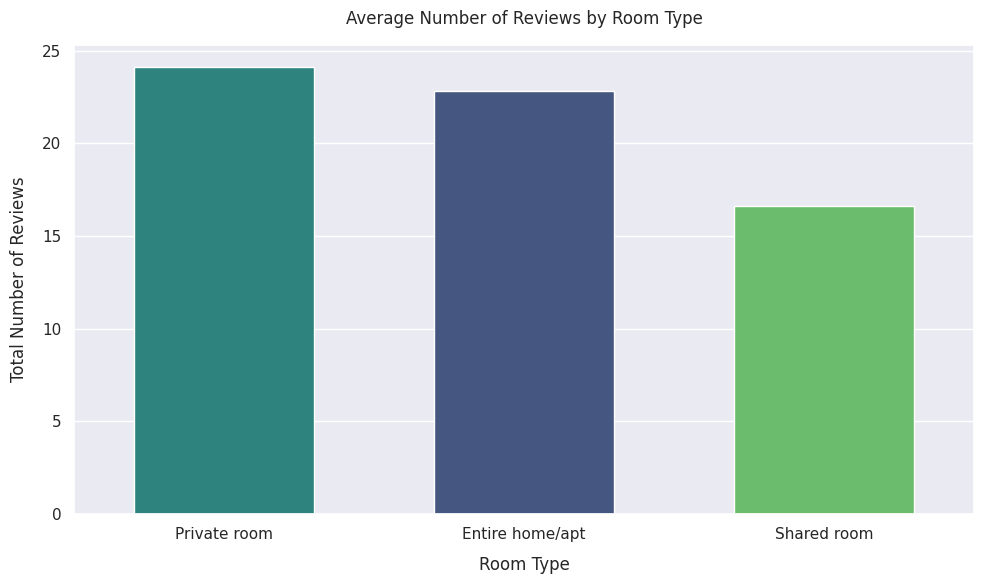

In [ ]:
# Calculate the total number of reviews for each room_type
total_reviews_by_room_type = airbnb_df.groupby('room_type', observed=False)['number_of_reviews'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='room_type', y='number_of_reviews', data=total_reviews_by_room_type, hue='room_type', palette='viridis', legend=False,
            order=total_reviews_by_room_type['room_type'], width=0.6)
plt.title('Average Number of Reviews by Room Type', pad=title_padding)
plt.xlabel('Room Type', labelpad=label_padding)
plt.ylabel('Total Number of Reviews', labelpad=label_padding)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot was selected to visualize the total `number_of_reviews` by `room_type` because it enables us to compare a numerical aggregate (total reviews) across categorical groups (room types).

This chart clearly shows which room types are generating the most guest feedback, offering insights into their popularity and guest engagement.

##### 2. What is/are the insight(s) found from the chart?

- **'Private room' receives the most reviews**: 'Private room' listings have the highest average number of reviews, exceeding other room types. Although the 'Entire home/apt' have the highest listing count and total number of reviews, private room type still received highest average indicating it's guests' preference and popularity. They experience a high volume of bookings, leading to more guest feedback.

- **'Entire home/apt' is also highly reviewed**: 'Entire home/apt' listings also has a substantial number of reviews, positioning them as a strong second. This indicates considerable guest activity and satisfaction within this room type.

- **'Shared room' receives the fewest reviews**: 'Shared room' listings have the lowest total number of reviews by a significant margin. This aligns with their lower listing count and potentially lower booking frequency.

- **Review Volume Reflects Popularity**: The total number of reviews can be an indicator of a room type's overall popularity, booking volume, and guest engagement. 'Private rooms' appear to be a high-traffic segment for guest interactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Market Positioning, Enhancing Guest Experience, Operational Strategy):**
- **Targeted Investment/Listing Strategy**: For new hosts, Investing in and optimizing 'Private room' listings can lead to quicker bookings and review accumulation, which are crucial for establishing a presence on the platform.
- **Focus on Guest Experience for High-Volume Types**: Since 'Private room' and 'Entire home/apt' receive the most reviews, hosts in these categories should prioritize excellent guest experiences. Positive reviews in these high-visibility segments can significantly boost a listing's reputation and search ranking, leading to more bookings.
- **Review Management**: Hosts with 'Private room' and 'Entire home/apt' listings should actively encourage and manage reviews. A higher volume of positive reviews acts as strong social proof, attracting more guests and creating a positive feedback loop.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Lack of Visibility for 'Shared room'**: The significantly lower review count for 'Shared room' could imply lower demand. New hosts entering this segment might struggle to get initial bookings and reviews, leading to a slow start.
- **Operational Strain for High-Volume Reviews**: Generating a high volume of reviews often means a high volume of bookings and guest interactions. If hosts couldn't handle the operational demands (e.g., communication, cleaning, maintenance) their service quality might suffer, leading to negative reviews and decline in growth.

#### Chart - 14: Line plot - Average price variation based on Minimum Nights

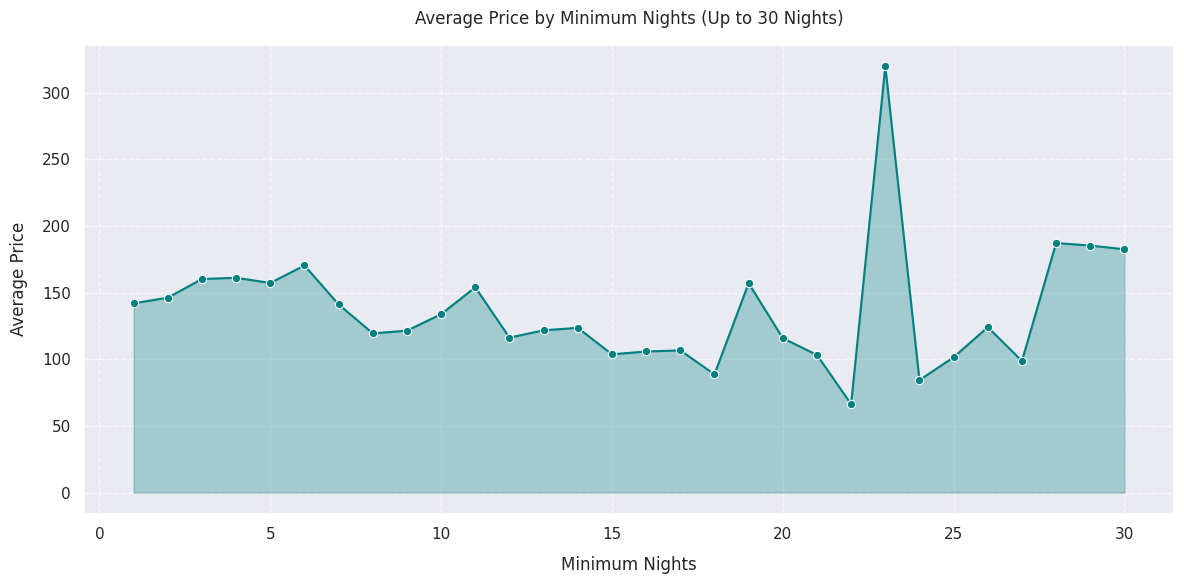

In [ ]:
# Filter out minimum_nights values greater than 30 to focus on common ranges
filtered_min_nights_df = airbnb_df[airbnb_df['minimum_nights'] <= 30]

# Calculate the average price for each minimum_nights value
avg_price_by_min_nights = filtered_min_nights_df.groupby('minimum_nights')['price'].mean().reset_index()

# Chart - 17 visualization code
plt.figure(figsize=(12, 6))
sns.lineplot(x='minimum_nights', y='price', data=avg_price_by_min_nights, marker='o', color='teal')
plt.fill_between(x=avg_price_by_min_nights['minimum_nights'], y1=avg_price_by_min_nights['price'], color='teal', alpha=0.3)
plt.title('Average Price by Minimum Nights (Up to 30 Nights)', pad=title_padding)
plt.xlabel('Minimum Nights', labelpad=label_padding)
plt.ylabel('Average Price', labelpad=label_padding)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line plot was chosen to visualize the trend of average price against `minimum_nights`. This chart type is effective for showing how a continuous numerical variable (average price) changes in relation to numerical variable (minimum nights).

By focusing on `minimum_nights` up to 30, we concentrate on the most common and relevant stay durations, allowing for a clearer observation of pricing patterns and potential strategies for hosts.

##### 2. What is/are the insight(s) found from the chart?

- **Premium for Short Stays (1-2 nights)**: There is a tendency for shorter minimum stays (1-2 nights) to command relatively high average prices, suggesting a premium for flexibility.
- **Price Drop for Longer Stays**: As the `minimum_nights` increases, especially beyond 10 nights, the average price generally tends to decrease. This indicates that hosts are willing to offer lower nightly rates for longer commitments to ensure occupancy.
- **High Variability around 15+ stays**: The plot shows some peaks and valleys in the range of 15 and 30 stays, showing varying demand for different stays across this specific range.
- **No Consistent Linear Relationship**: The relationship is nowhere linear, indicating that pricing strategies are nuanced and depend on various factors beyond just the minimum stay duration.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization & Market Positioning):**
*   **Dynamic Pricing Strategy**: Hosts can leverage the observation that shorter stays (1-2 nights) often command higher average prices. They can strategically increase prices for these shorter, flexible bookings to maximize revenue, especially during peak demand periods. Conversely, for longer stays (e.g., 30 nights), offering discouts can ensure higher occupancy and consistent income, which is crucial for overall revenue optimization.
- **Targeting Traveler Segments**: The data suggests that short stays cater to tourists or business travelers who need flexibility. Hosts can tailor their listing descriptions and amenities to attract specific segments, improving market positioning.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Over-reliance on Short Stays**: While short stays can yield higher nightly rates, they often come with higher operational costs (cleaning, guest communication, check-ins/outs). An exclusive focus on short stays without efficient operations could lead to reduced profitability despite high ADR.

### Multi-variate Analysis - 2 Charts (15-16)

#### Chart - 15: Bar plot - Average Price Distribution by Stay Type across Room Types

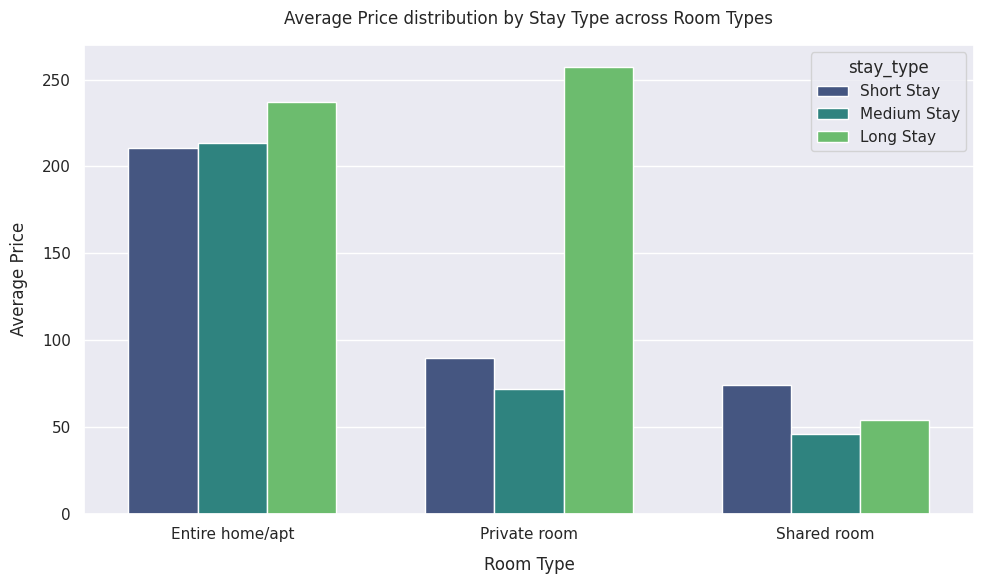

In [ ]:
# Calculate the average price for each combination of room_type and stay_type
avg_price_room_stay = airbnb_df.groupby(['room_type', 'stay_type'], observed=False)['price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='room_type', y='price', hue='stay_type', data=avg_price_room_stay, palette='viridis', width=0.7)
plt.title('Average Price distribution by Stay Type across Room Types', pad=title_padding)
plt.xlabel('Room Type', labelpad=10)
plt.ylabel('Average Price', labelpad=10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to visualize the distribution of average price across `stay_type` within each `room_type`. This chart shows how stay types command different average listing prices revealing how the market prefers stay duration based on the type of accommodation.

##### 2. What is/are the insight(s) found from the chart?

- **'Long Stay' commands the highest average price**: Significantly exceeding 'Medium Stay' and 'Short Stay', the 'Long Stay' has the highest average price. This suggests that, properties available for extended periods are either inherently more luxurious, located in prime areas, or hosts are able to maintain a higher average daily rate for these longer bookings.
- **High and Similar average pricing for all Stay types in 'Entire home/apt'**: Shows the market depend across all duration types for this particular room type, significantly higher in overall average from the other room types.
- **'Medium and Short Stay' is moderately priced**: They have a lower average price than 'Long Stay' and it positions them as a mid-range option.
- **Private room has high average for 'Long stay' duration**: It's evident that travellers seeking long duration often prefer privacy centered room types and this combination puts the pricing into it's higher side of ths spectrum.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization & Market Positioning):**
 - **Strategic Pricing for Long Stays**: Hosts with properties suitable for 'Long Stay' (more than 30 nights) can potentially command higher average prices. They should focus on amenities and services that cater to extended guests.
 - **Understanding Market Segments**: The clear distinction in average prices across stay types helps hosts understand different guest segments and their willingness to pay, allowing for more precise market positioning.
**Insights Leading to Negative Growth (Potential Concerns):**
 - **Competitive Pressure for Short and Medium Stays**: The lower average prices for 'Short Stay' and 'Medium Stay' suggest these segments are highly competitive. Hosts in these categories might face significant pressure to keep prices low, potentially reducing profit margins and making it difficult to achieve substantial growth without strong differentiation.
 -  **Operational Demands**: While long stays might seem more profitable on average, they come with their own operational demands, fewer turnovers but potentially higher wear and tear. Inefficient management of these factors could negate the benefit of higher average prices.

#### Chart - 16: Correlation Heatmap of Numerical Features

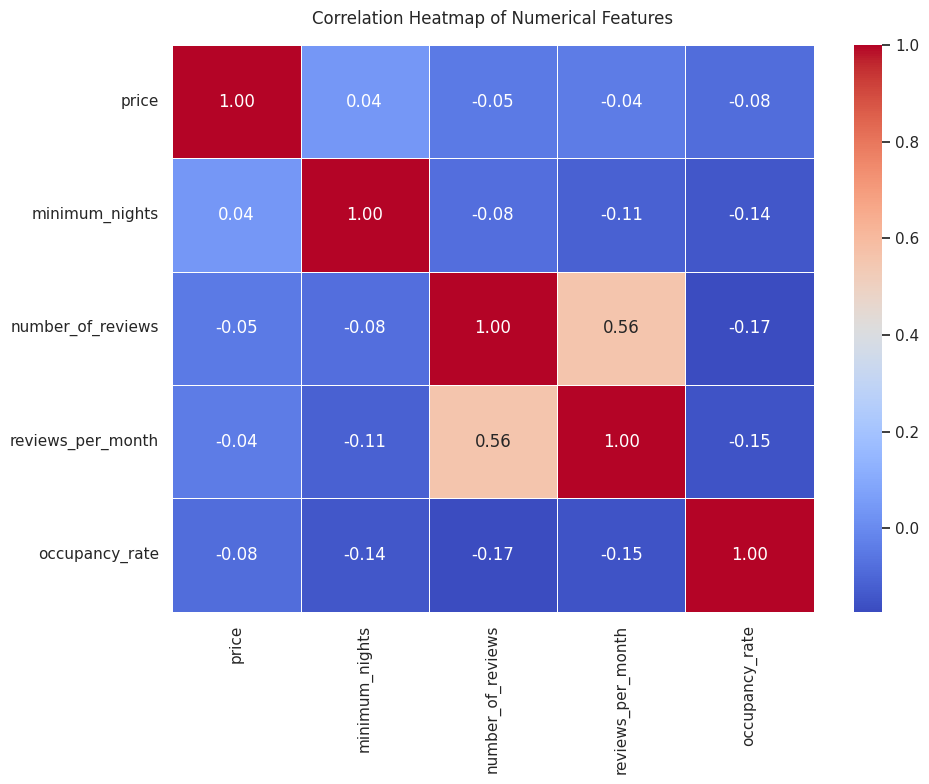

In [ ]:
# Select numerical columns for correlation analysis
# Exclude 'id' and 'host_id' as they are identifiers and not numerical features for correlation
numerical_df = airbnb_df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'occupancy_rate']]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', pad=title_padding)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to visualize the relationships between the numerical variables in the dataset. It includes the `occupancy_rate` (a generated parameter) for relevance.

This chart helps quickly identify which numerical features are strongly correlated (positively or negatively) with `price` or others. Understanding these correlations is crucial for feature selection in potential predictive modeling, as well as for gaining insights into how different quantitative aspects of a listing influence each other.

##### 2. What is/are the insight(s) found from the chart?

- **Weak Correlation with Price**: `price` shows very weak correlations with most other numerical features. This suggests that price is not strongly linearly dependent on these individual factors in a straightforward manner.
- **Strong Positive Correlation between `number_of_reviews` and `reviews_per_month`**: As expected, a strong positive correlation (0.56) between `number_of_reviews` and `reviews_per_month`. This indicates that listings with more total reviews also tend to receive more reviews per month, implying consistent popularity.

Overall, the heatmap suggests that while some relationships exist, many numerical variables are not linearly correlated with each other, particularly with `price`. This implies that price might be influenced by a more complex mix of factors which can't be captured with a quantitative sense.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact (Revenue Optimization, Market Positioning, Enhancing Guest Experience):**
- **Focus on Non-Linear Factors**: Since price has weak linear correlations with numerical features, hosts and the platform should focus on optimizing categorical factors (like `room_type`, `neighbourhood_group`), and guest experience to drive pricing and demand.
- **Leverage Review Consistency**: The strong correlation between `number_of_reviews` and `reviews_per_month` indicates that consistently good performance leads to sustained review activity. Hosts should prioritize exceptional guest experiences to generate more reviews, creating a sustainable positive feedback loop that helps in generating more demand and thus revenue.

**Insights Leading to Negative Growth (Potential Concerns):**
- **Over-reliance on Numerical Metrics for Pricing**: Given the weak correlation of `price` with most numerical factors, a host solely relying on these metrics for pricing might misprice their listing, leading to missed revenue opportunities.
- **Misinterpreting Availability**: A listing with high `availability_365` but low reviews/bookings might indicate an underperforming asset. If this goes unaddressed, it represents a direct loss of potential revenue, hosts need to actively manage the property to reduce the period of unavailability.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Achieving Revenue Optimization (Pricing Strategy)**
    - **Target the \$100–\$200 bracket**: The initial distribution of pricing and the average price variation across boroughs and room types indicate the highly available price point is between this target range and could potentially lead to higher booking rates if listing is located in high demand area, generating consistent revenue and yielding better profit margins.
    - **Exert a Premium for Entire Home/Apt**: Especially in Manhattan, proves that 'Entire Home/apt' properties usually command the ceiling of the market's pricing. So, hosts holding these specific assets should price aggressively above the standard borough median.

2. **Achieving Market Position (Supply & Demand)**
    - **Differentiate the Offering**: Count plots indicate that marked supply is heavily saturated in Manhattan and Brooklyn, which means high competition for various price ranges, unless hosts of these properties differentiate their listings through unique guest experiences and services they may face fallback in bookings.
    - **Capitalize on Underserved Boroughs**: Hosts can consider the less competitive markets in boroughs like Queens, Staten Island and Bronx to further expand their investments to capture though comparitively small market, there still exists a steady demand.

3. **Achieving Enhanced Guest Experience**
    - **Lower the Minimum Night Barrier**: As seen from the stay type based listings and pricing plots, the more popular duration for the guests who are mostly the travellers is 'short term'. This particular stay type tends to stay in high demand all the time compared to higher stay durations. In the context of this data, hosts should consider lowering the stay duration if not completely at least for shorter term to revive poor performing listings that exhibits low bookings and review counts. This could potentially attracts frequent bookings which in turn triggers quicker feedback loops that supports the demand for higher occupancy rate.
    - **Monitor Bookings and Feedback Metrics**: Establish proper monitoring system via hosting platform to flag the listings that gets almost zero bookings or when reviews per month falls to zero. This indicates that these properties are drifting out of market relevance, so knowing which listings are failing is the first thing to tackle the problem. By considering occational pricing discounts and improved descriptions can revive the listings into search results and increase visibility, leading to bookings.

# **Conclusion**

### **Technical Framework and Execution**

This exploratory data analysis followed a structured data pipeline by pre-handling the dataset before analysis, which included handling of over 10k missing records in key review tracking metrics and resolving structural anomalies in descriptive based fields and optimizing the data types for efficient processing.

The analysis part was applied with a disciplined *Univariate*, *Bivariate*, and *Multivariate* (*UBM*) approach, uncovering insights in a sequential setting. Generated new fields based on existing parameters that further provided visibility into the underlying patterns of the market behavior towards different boroughs and properties.


### **Final Strategic Impact**

By moving beyond basic, un-targeted plotting, this notebook bridges the gap between the raw data and strategic host positioning. The insights derived provide a overall picture for optimizing pricing, standardizing operations and tackling underperforming assets, to move towards generating a consistent revenue that yields better profit margins. This data-driven analysis serves as a decision making tool eliminating guesswork and allowing hosts and stakeholders to position their rentals for high growth and optimized revenue in a highly competitive and underserved markets.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

# ---------------- END -----------------